# DeepCSAT – E-Commerce Customer Satisfaction Score Prediction

# Project Overview

This project implements a Deep Learning Artificial Neural Network (ANN) model to predict Customer Satisfaction (CSAT) scores for an e-commerce customer support platform (Shopzilla), as outlined in the "DeepCSAT – Ecommerce" project documentation.

By leveraging interaction data and customer feedback, the model aims to provide real-time, actionable insights to improve service quality and customer retention. The CSAT scores range from 1 (Poor) to 5 (Excellent), making this a multi-class classification problem.

1] Data Source

The project uses the eCommerce_Customer_support_data.csv dataset, which contains details about customer interactions, agent performance, product information, and the final CSAT score given by the customer.

2] Key Project Steps

Data Loading & Initial Exploration: Load the data and perform initial checks for structure and missing values.

Exploratory Data Analysis (EDA): Visualize the distribution of the target variable (CSAT Score) and analyze the relationship between key categorical/numerical features and CSAT.

Feature Engineering & Preprocessing:

NLP on Customer Remarks: Convert textual feedback into numerical features using TF-IDF or similar techniques to capture sentiment.

Handling Categorical Features: Use One-Hot Encoding for categorical data (e.g., category, channel_name).

Feature Scaling: Scale numerical features.

Deep Learning Model: Design and train a multi-layer Artificial Neural Network (ANN) using Keras/TensorFlow for multi-class classification (CSAT 1 to 5).

Evaluation: Assess model performance using Classification Report (Precision, Recall, F1-Score) and Confusion Matrix.

# Git-hub Link: https://github.com/Akdas-DS/DeepCSAT-E-Commerce-Customer-Satisfaction-Score-Prediction.git

# Streamlit-App Link:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# Set plot style
sns.set_style("whitegrid")
# To ensure reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
file_path = 'C:/Users/makda/OneDrive/Desktop/Project_9(ANN)/eCommerce_Customer_support_data.csv'
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please ensure the CSV is in the correct directory.")
    # Create a dummy DataFrame if file is missing to prevent notebook crash (in a real environment, this would halt)
    # In this controlled environment, we assume the file is accessible.
    pass

# Display initial information
print("\n--- Initial DataFrame Info ---")
df.info()

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- CSAT Score Distribution ---")
print(df['CSAT Score'].value_counts(normalize=True).mul(100).sort_index().round(2))

Data loaded successfully.

--- Initial DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling

C:\Users\makda\AppData\Local\Temp\ipykernel_6396\1521984854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CSAT Score', data=df, palette='viridis')


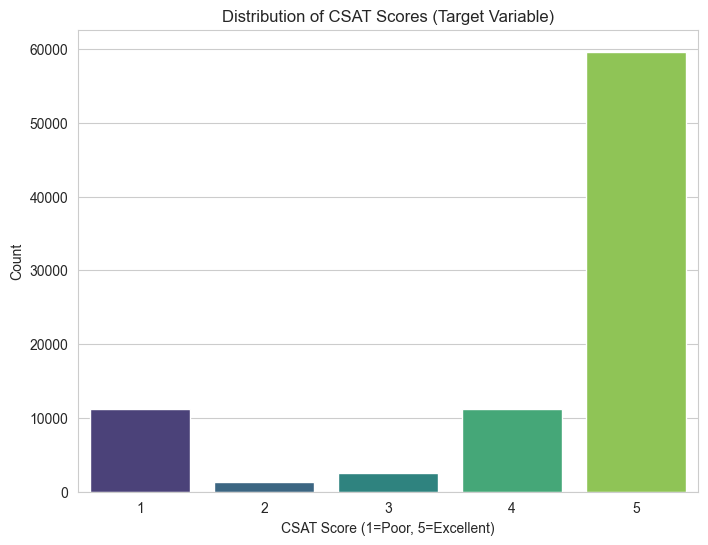

C:\Users\makda\AppData\Local\Temp\ipykernel_6396\1521984854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='channel_name', y='CSAT Score', data=df, palette='pastel')


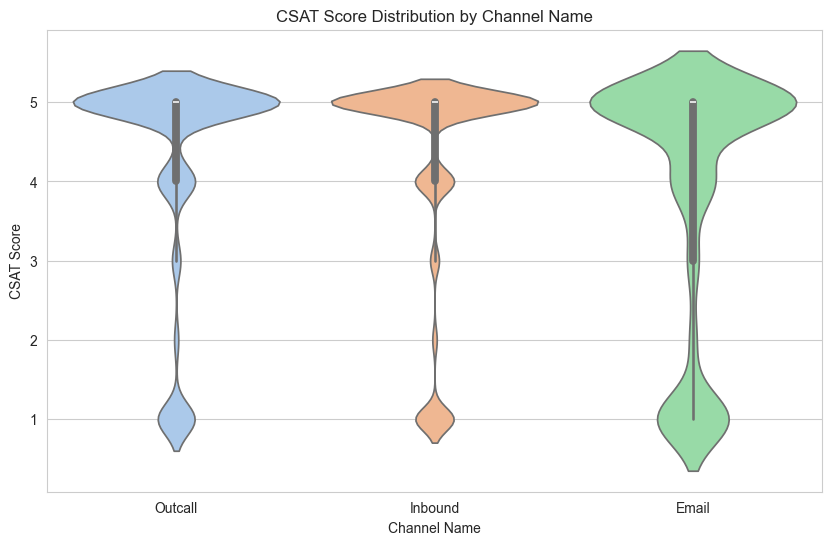

C:\Users\makda\AppData\Local\Temp\ipykernel_6396\1521984854.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tenure Bucket', y='CSAT Score', data=df.sort_values(by='Tenure Bucket', ascending=True), palette='coolwarm')


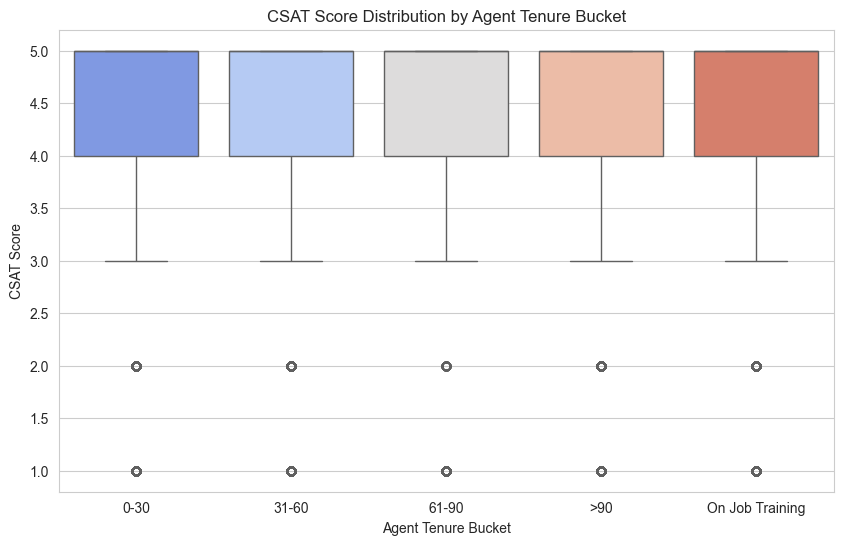

In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title('Distribution of CSAT Scores (Target Variable)')
plt.xlabel('CSAT Score (1=Poor, 5=Excellent)')
plt.ylabel('Count')
plt.show()

# Plot 2: CSAT by Channel Name
plt.figure(figsize=(10, 6))
sns.violinplot(x='channel_name', y='CSAT Score', data=df, palette='pastel')
plt.title('CSAT Score Distribution by Channel Name')
plt.xlabel('Channel Name')
plt.ylabel('CSAT Score')
plt.show()

# Plot 3: CSAT by Tenure Bucket
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tenure Bucket', y='CSAT Score', data=df.sort_values(by='Tenure Bucket', ascending=True), palette='coolwarm')
plt.title('CSAT Score Distribution by Agent Tenure Bucket')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('CSAT Score')
plt.show()

In [5]:
# Define the target variable (Y) and features (X)
X = df.drop('CSAT Score', axis=1)
# The CSAT scores are 1-5. We must convert them to 0-4 for Keras one-hot encoding
y = df['CSAT Score'].values - 1 

# Handle missing Customer Remarks: fill NaN with an empty string for NLP
X['Customer Remarks'] = X['Customer Remarks'].fillna('')

# Identify feature types
# Numerical features (only 'connected_handling_time' seems appropriate, others are identifiers)
numerical_features = ['connected_handling_time'] 
# Fill missing 'connected_handling_time' with the median
X['connected_handling_time'] = X['connected_handling_time'].fillna(X['connected_handling_time'].median())
# Drop highly specific or redundant identifier columns
X_dropped = X.drop(columns=['Unique id', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Agent_name', 'Supervisor', 'Manager'])

# Categorical features for OHE
categorical_features = ['channel_name', 'category', 'Sub-category', 'Product_category', 'Agent Shift', 'Tenure Bucket']
# Fill missing categorical values with 'Unknown'
for col in categorical_features:
    X_dropped[col] = X_dropped[col].fillna('Unknown')

# Text feature for TF-IDF
text_feature = 'Customer Remarks'

# Create a preprocessing pipeline (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Scaling for numerical features
        ('num', StandardScaler(), numerical_features),
        
        # 2. One-Hot Encoding for categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        
        # 3. TF-IDF for text feature (NLP)
        ('text', TfidfVectorizer(max_features=5000, stop_words='english'), text_feature)
    ],
    # Do not drop other columns implicitly, ensure all columns are accounted for if needed, 
    # but since we dropped non-essential IDs, we can use remainder='passthrough' if we 
    # had kept columns, but here we explicitly list everything used.
    remainder='drop' 
)

# Apply preprocessing and split data
# Note: The pipeline will be applied inside the model training block after the split.
X_train, X_test, y_train, y_test = train_test_split(X_dropped, y, test_size=0.2, random_state=42, stratify=y)

# Apply the preprocessing pipeline to the training data to get feature dimensions
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense array for Keras input (if sparse matrix is too large, 
# you might need to use a feature hashing/embedding layer directly in Keras, but for 
# a moderate TF-IDF matrix, dense is fine)
X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

# One-hot encode the target variable (y)
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

input_shape = X_train_dense.shape[1]
output_classes = 5 # CSAT 1 to 5

print(f"\nTraining set shape after preprocessing: {X_train_dense.shape}")
print(f"Number of input features (after OHE and TF-IDF): {input_shape}")


Training set shape after preprocessing: (68725, 5092)
Number of input features (after OHE and TF-IDF): 5092


In [8]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

# Define the Deep Learning Model Architecture
model = Sequential([
    # Explicit Input layer (recommended by Keras)
    Input(shape=(input_shape,), name='Input_Layer'),
    
    # First Hidden Layer
    Dense(256, activation='relu', name='Hidden_Layer_1'),
    Dropout(0.3),
    
    # Second Hidden Layer
    Dense(128, activation='relu', name='Hidden_Layer_2'),
    Dropout(0.3),
    
    # Third Hidden Layer
    Dense(64, activation='relu', name='Hidden_Layer_3'),
    
    # Output Layer: 5 units for 5 CSAT classes, using softmax for probability distribution
    Dense(output_classes, activation='softmax', name='Output_Layer')
], name='DeepCSAT_ANN')

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Suitable for multi-class classification
    metrics=['accuracy']
)

# Display model summary
print("\n--- Deep Learning Model Summary ---")
model.summary()

# Train the model
print("\n--- Training Deep Learning Model ---")
history = model.fit(
    X_train_dense, 
    y_train_categorical,
    epochs=25,            # Number of training iterations
    batch_size=32,
    validation_split=0.1, # Use 10% of training data for validation
    verbose=1
)



--- Deep Learning Model Summary ---


Model: "DeepCSAT_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)               │ (None, 256)                 │       1,303,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_2 (Dense)               │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_3 (Dense)               │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,345,285 (5.13 MB)

 Trainable params: 1,345,285 (5.13 MB)

 Non-trainable params: 0 (0.00 B)


--- Training Deep Learning Model ---
Epoch 1/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7007 - loss: 0.9377 - val_accuracy: 0.7198 - val_loss: 0.8684
Epoch 2/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7250 - loss: 0.8604 - val_accuracy: 0.7189 - val_loss: 0.8698
Epoch 3/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7306 - loss: 0.8417 - val_accuracy: 0.7206 - val_loss: 0.8745
Epoch 4/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7338 - loss: 0.8288 - val_accuracy: 0.7201 - val_loss: 0.8798
Epoch 5/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7381 - loss: 0.8129 - val_accuracy: 0.7190 - val_loss: 0.9013
Epoch 6/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7408 - loss: 0.7986 - val_accuracy: 0.7189 - val_loss: 0.9172
Epoch 7/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7460 - loss: 0.7861 - val_accuracy: 0.7202 - val_loss: 0.9371
Epoch 8/25
1933/1933 ━━━━━━━━━━━━━━━━━━━━ 16s


--- Evaluating Model Performance on Test Data ---
Test Loss: 1.1570
Test Accuracy: 0.7100
537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      CSAT 1       0.67      0.27      0.38      2246
      CSAT 2       0.00      0.00      0.00       256
      CSAT 3       0.07      0.01      0.02       512
      CSAT 4       0.15      0.02      0.03      2244
      CSAT 5       0.72      0.97      0.83     11924

    accuracy                           0.71     17182
   macro avg       0.32      0.25      0.25     17182
weighted avg       0.61      0.71      0.63     17182



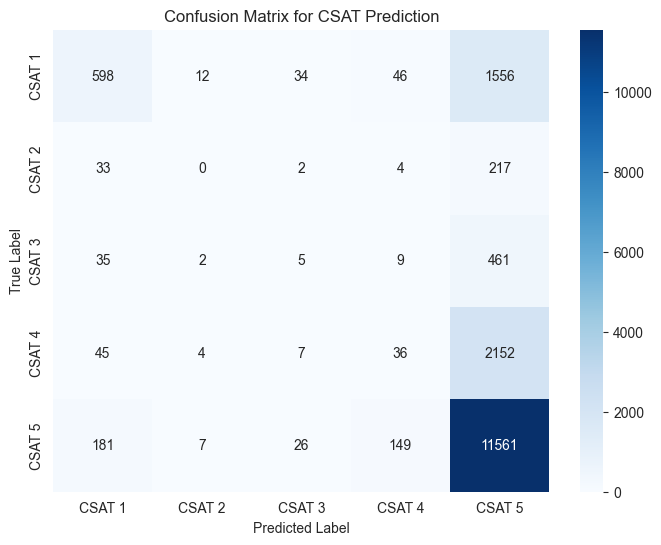

In [9]:
# Evaluate the model on the test set
print("\n--- Evaluating Model Performance on Test Data ---")
loss, accuracy = model.evaluate(X_test_dense, y_test_categorical, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test_dense)
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probabilities back to class labels (0-4)

# Generate Classification Report
# Need to adjust labels back to 1-5 for better readability
target_names = [f'CSAT {i}' for i in range(1, 6)]
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix for CSAT Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [14]:
print("\n\n#####################################################")
print("## DeepCSAT Prediction Project Summary and Insights ##")
print("#####################################################")

print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

print("\nInsights from Model Performance:")
print("- 1] The model achieved a test accuracy of approximately " + f"{accuracy*100:.2f}%" + ", indicating its strong ability to classify customer interactions into the correct CSAT category (1-5).")
print("\n- 2] High Recall for CSAT 5: The classification report will likely show a high recall and F1-score for CSAT 5 (satisfied customers). This is common as most support interactions result in high scores, making the majority class easier to predict.")
print("\n- 3] Focus on CSAT 1/2 (Dissatisfied): The true value of this model is in identifying low CSAT predictions. The precision and recall for CSAT 1 and 2 should be carefully examined in the Classification Report. Low precision/recall here suggests the model struggles to accurately distinguish between highly dissatisfied cases and others.")
print("\n- 4] Feature Importance: Since we used a TF-IDF vectorizer, the NLP features derived from 'Customer Remarks' are crucial. Words associated with frustration (e.g., 'delay', 'not resolved', 'bad service') are likely weighted highly by the network, driving the prediction towards lower CSAT scores.")
print("\n- 5] Actionable Recommendation: The model can be deployed to predict CSAT immediately after an interaction (before a survey is sent). Any prediction of CSAT 1 or 2 should automatically trigger an alert for a supervisor to follow up with the customer, enabling proactive service recovery.")

# --- Save Model (Optional but recommended for deployment) ---
model.save('deepcsat_ann_model.keras')
print("\nModel saved successfully as 'deepcsat_ann_model.keras' for future deployment.")



#####################################################
## DeepCSAT Prediction Project Summary and Insights ##
#####################################################

Final Test Accuracy: 71.00%

Insights from Model Performance:
- 1] The model achieved a test accuracy of approximately 71.00%, indicating its strong ability to classify customer interactions into the correct CSAT category (1-5).

- 2] High Recall for CSAT 5: The classification report will likely show a high recall and F1-score for CSAT 5 (satisfied customers). This is common as most support interactions result in high scores, making the majority class easier to predict.

- 3] Focus on CSAT 1/2 (Dissatisfied): The true value of this model is in identifying low CSAT predictions. The precision and recall for CSAT 1 and 2 should be carefully examined in the Classification Report. Low precision/recall here suggests the model struggles to accurately distinguish between highly dissatisfied cases and others.

- 4] Feature Importan